# MNIST Handwritten Digit Classification using Neural Networks

### Deep Learning Lab Project

This project implements handwritten digit classification using the MNIST dataset and TensorFlow/Keras.

The project covers:
- Dataset exploration
- Data preprocessing
- Neural network development
- Model training
- Model evaluation
- Digit prediction
- Architecture experimentation
- Performance comparison


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

In [2]:
# Set random seeds so that results are more reproducible
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("\nDataset Loaded Successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Dataset Loaded Successfully!


In [5]:
print("Training images shape :", X_train.shape)
print("Training labels shape :", y_train.shape)
print("Testing images shape  :", X_test.shape)
print("Testing labels shape  :", y_test.shape)

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing images shape  : (10000, 28, 28)
Testing labels shape  : (10000,)


In [6]:
print("\nDATA EXPLORATION")


DATA EXPLORATION


In [7]:
print("Image shape:", X_train[0].shape)


Image shape: (28, 28)


In [8]:

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())


Minimum pixel value: 0
Maximum pixel value: 255


In [9]:
print("First 20 training labels:")
print(y_train[:20])

First 20 training labels:
[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]


In [10]:
print("Unique digit classes:")
print(np.unique(y_train))

Unique digit classes:
[0 1 2 3 4 5 6 7 8 9]


In [11]:
# Count number of samples for each digit
unique, counts = np.unique(y_train, return_counts=True)

class_distribution = pd.DataFrame({
    "Digit": unique,
    "Number of Images": counts
})

print("\nClass Distribution:")
display(class_distribution)


Class Distribution:


,Digit,Number of Images
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


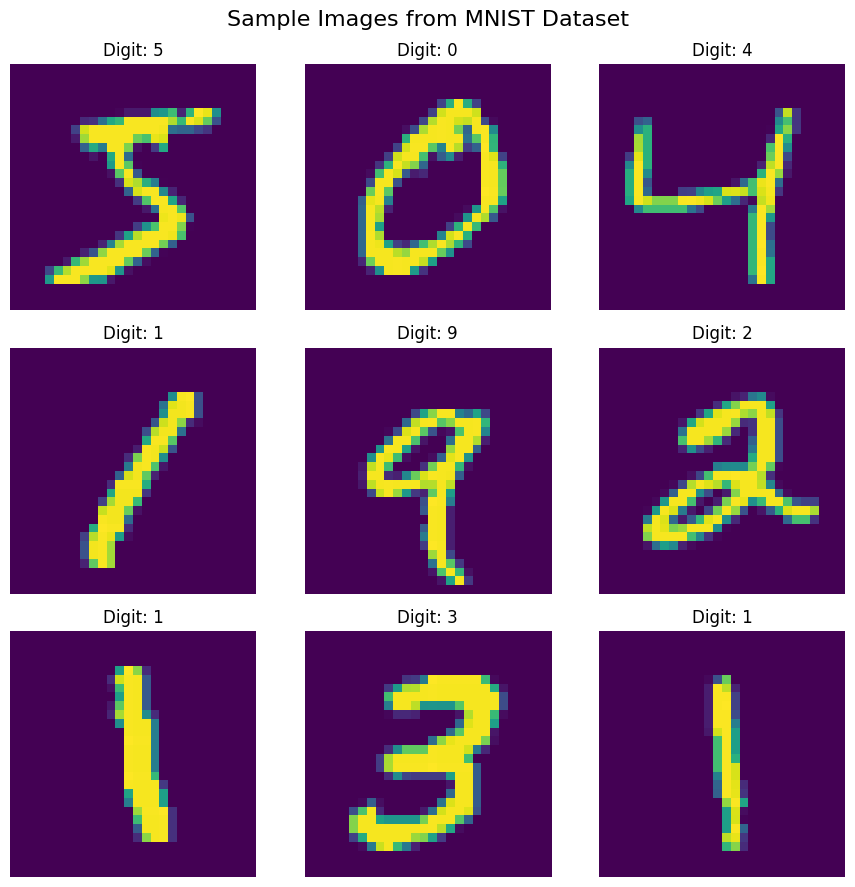

In [12]:
plt.figure(figsize=(9, 9))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Display image in grayscale
    plt.imshow(X_train[i])

    # Display actual label
    plt.title(f"Digit: {y_train[i]}")

    plt.axis("off")

plt.suptitle("Sample Images from MNIST Dataset", fontsize=16)
plt.tight_layout()
plt.show()

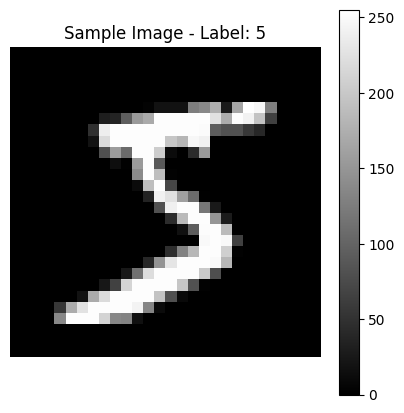

Shape of selected image: (28, 28)


In [13]:
# Select one image
sample_image = X_train[0]

plt.figure(figsize=(5, 5))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample Image - Label: {y_train[0]}")
plt.colorbar()
plt.axis("off")
plt.show()

print("Shape of selected image:", sample_image.shape)

In [16]:
# Original pixel values are between 0 and 255.
# Convert them to floating-point values between 0 and 1.

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("\nDATA AFTER NORMALIZATION")

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())



DATA AFTER NORMALIZATION
Minimum pixel value: 0.0
Maximum pixel value: 0.003921569


In [18]:
# Output = probabilities for digits 0 to 9

model = Sequential([

    # Define input shape
    Input(shape=(28, 28)),

    # Convert 28x28 image into a 784-element vector
    Flatten(),

    # First hidden layer
    Dense(128, activation="relu"),

    # Second hidden layer
    Dense(32, activation="relu"),

    # Output layer with 10 classes
    Dense(10, activation="softmax")
])


# Display model architecture
print("\nBASELINE MODEL SUMMARY")

model.summary()


BASELINE MODEL SUMMARY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel compiled successfully!")



Model compiled successfully!


In [20]:
#TRAIN BASE MODEL
history = model.fit(
    X_train,
    y_train,

    # Number of complete passes through training data
    epochs=25,

    # 20% of training data will be used for validation
    validation_split=0.20,

    # Number of samples processed before updating weights
    batch_size=32,

    verbose=1
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6879 - loss: 1.0271 - val_accuracy: 0.8547 - val_loss: 0.5035
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8660 - loss: 0.4601 - val_accuracy: 0.8853 - val_loss: 0.3912
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8862 - loss: 0.3931 - val_accuracy: 0.8982 - val_loss: 0.3527
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8971 - loss: 0.3571 - val_accuracy: 0.9070 - val_loss: 0.3238
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9055 - loss: 0.3276 - val_accuracy: 0.9138 - val_loss: 0.2996
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9129 - loss: 0.3026 - val_accuracy: 0.9195 - val_loss: 0.2801
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9193 - loss: 0.2809 - val_accuracy: 0.9244 - val_loss: 0.2627
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9243 - loss: 0.2618 - 

In [21]:
#evaluation model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nBASELINE MODEL RESULTS")


print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


BASELINE MODEL RESULTS
Test Loss     : 0.1284
Test Accuracy : 96.27%


In [22]:
# model.predict() returns probabilities for all 10 classes
y_probability = model.predict(X_test, verbose=0)

# Select class having highest probability
y_pred = np.argmax(y_probability, axis=1)

print("\nFIRST 20 PREDICTIONS")


print("Actual labels    :", y_test[:20])
print("Predicted labels :", y_pred[:20])


FIRST 20 PREDICTIONS
Actual labels    : [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
Predicted labels : [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]


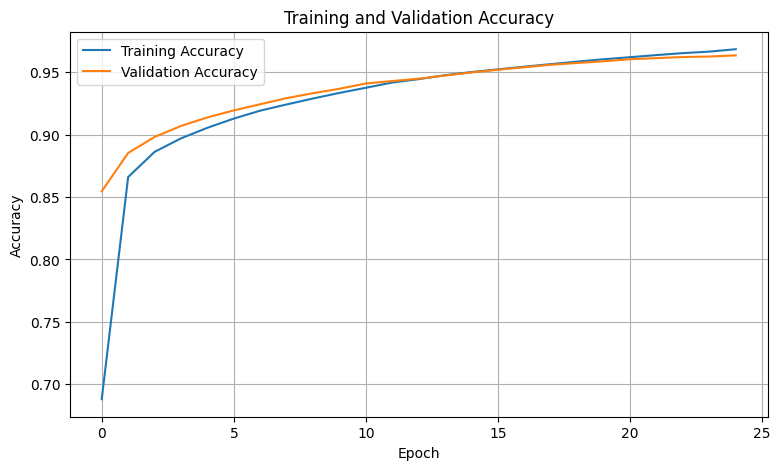

In [23]:
#training vs validation accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

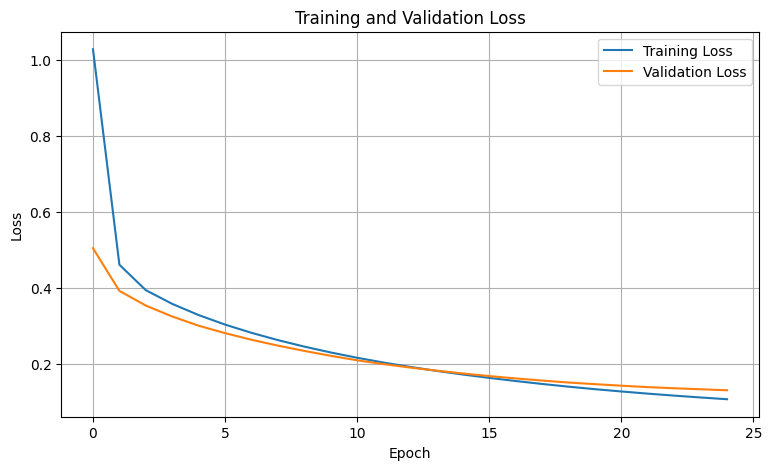

In [24]:
#training vs validation loss
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()


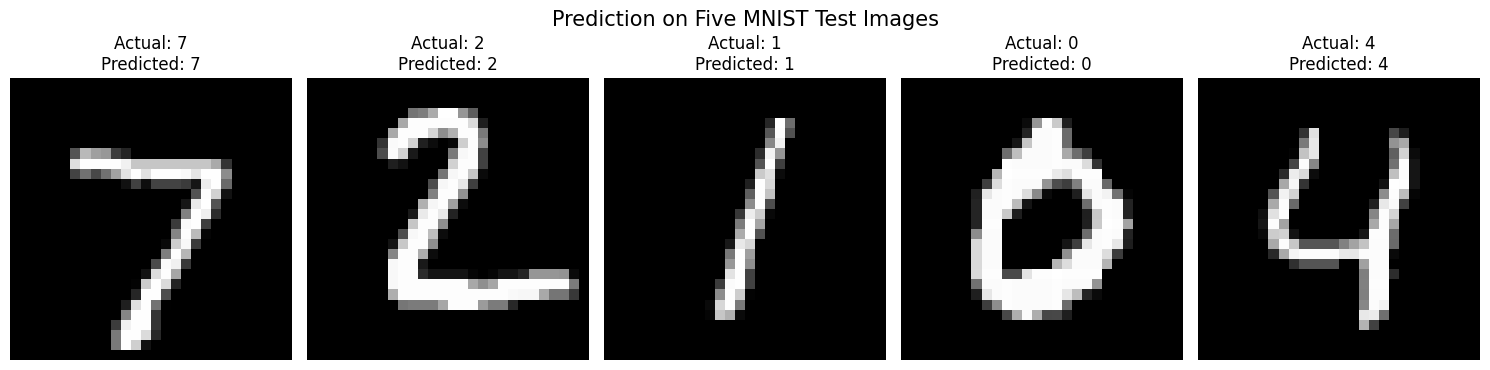

In [25]:
# Select five images from the test dataset
selected_indices = [0, 1, 2, 3, 4]

prediction_results = []

plt.figure(figsize=(15, 4))

for position, index in enumerate(selected_indices):

    # Get image
    image = X_test[index]

    # Add batch dimension because model expects:
    # (batch_size, 28, 28)
    image_input = image.reshape(1, 28, 28)

    # Predict probabilities
    prediction = model.predict(
        image_input,
        verbose=0
    )

    # Get predicted digit
    predicted_label = np.argmax(prediction)

    # Get actual digit
    actual_label = y_test[index]

    # Check whether prediction is correct
    result = (
        "Correct"
        if predicted_label == actual_label
        else "Incorrect"
    )

    # Store result
    prediction_results.append([
        index,
        actual_label,
        predicted_label,
        result
    ])

    # Display image
    plt.subplot(1, 5, position + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}"
    )
    plt.axis("off")

plt.suptitle(
    "Prediction on Five MNIST Test Images",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [26]:
# CREATING FIVE-IMAGE PREDICTION TABLE

prediction_df = pd.DataFrame(
    prediction_results,
    columns=[
        "Image Index",
        "Actual Label",
        "Predicted Label",
        "Result"
    ]
)

print("\nFIVE IMAGE PREDICTION RESULTS")
print("-" * 50)

display(prediction_df)


FIVE IMAGE PREDICTION RESULTS
--------------------------------------------------


,Image Index,Actual Label,Predicted Label,Result
0,0,7,7,Correct
1,1,2,2,Correct
2,2,1,1,Correct
3,3,0,0,Correct
4,4,4,4,Correct


In [27]:
# Increase the number of neurons in hidden layers.
#
# Baseline:
# 128 → 32 → 10
#
# Experimental:
# 256 → 64 → 10
#
# Other parameters remain unchanged.

experiment_model = Sequential([

    Input(shape=(28, 28)),

    Flatten(),

    # Increased from 128 to 256 neurons
    Dense(256, activation="relu"),

    # Increased from 32 to 64 neurons
    Dense(64, activation="relu"),

    Dense(10, activation="softmax")
])


# Display experimental model summary
print("\nEXPERIMENTAL MODEL SUMMARY")


experiment_model.summary()


EXPERIMENTAL MODEL SUMMARY


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



In [31]:
experiment_history = experiment_model.fit(
    X_train,
    y_train,
    epochs=25,
    validation_split=0.20,
    batch_size=32,
    verbose=1
)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9266 - loss: 0.2528 - val_accuracy: 0.9352 - val_loss: 0.2262
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9343 - loss: 0.2255 - val_accuracy: 0.9411 - val_loss: 0.2049
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9412 - loss: 0.2014 - val_accuracy: 0.9468 - val_loss: 0.1864
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9467 - loss: 0.1809 - val_accuracy: 0.9512 - val_loss: 0.1719
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9515 - loss: 0.1636 - val_accuracy: 0.9549 - val_loss: 0.1598
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9554 - loss: 0.1489 - val_accuracy: 0.9576 - val_loss: 0.1501
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9592 - loss: 0.1361 - val_accuracy: 0.9591 - val_loss: 0.1422
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9631 - loss: 0.1246 

In [32]:
# EVALUATE EXPERIMENTAL MODEL


experiment_loss, experiment_accuracy = experiment_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nEXPERIMENTAL MODEL RESULTS")


print(f"Experimental Test Loss     : {experiment_loss:.4f}")
print(
    f"Experimental Test Accuracy : "
    f"{experiment_accuracy * 100:.2f}%"
)


EXPERIMENTAL MODEL RESULTS
Experimental Test Loss     : 0.0903
Experimental Test Accuracy : 97.31%


In [33]:
# COMPARE BASELINE AND EXPERIMENTAL MODELS


comparison = pd.DataFrame({

    "Model": [
        "Baseline",
        "Experimental"
    ],

    "Hidden Layers": [
        "128, 32",
        "256, 64"
    ],

    "Epochs": [
        25,
        25
    ],

    "Test Accuracy (%)": [
        test_accuracy * 100,
        experiment_accuracy * 100
    ],

    "Test Loss": [
        test_loss,
        experiment_loss
    ]
})

print("\nMODEL COMPARISON")
print("-" * 50)

display(comparison)



MODEL COMPARISON
--------------------------------------------------


,Model,Hidden Layers,Epochs,Test Accuracy (%),Test Loss
0,Baseline,"128, 32",25,96.270001,0.128382
1,Experimental,"256, 64",25,97.310001,0.090279


In [34]:
# CALCULATE ACCURACY DIFFERENCE


accuracy_difference = (
    experiment_accuracy - test_accuracy
) * 100

print(
    f"Difference in Test Accuracy: "
    f"{accuracy_difference:.2f}%"
)

Difference in Test Accuracy: 1.04%


In [35]:
# CALCULATE ACCURACY DIFFERENCE


accuracy_difference = (
    experiment_accuracy - test_accuracy
) * 100

print(
    f"Difference in Test Accuracy: "
    f"{accuracy_difference:.2f}%"
)

Difference in Test Accuracy: 1.04%


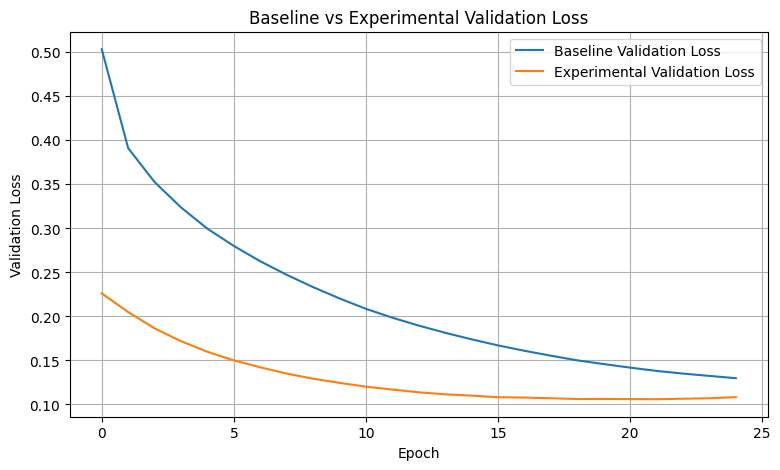

In [36]:
# COMPARE VALIDATION LOSS


plt.figure(figsize=(9, 5))

plt.plot(
    history.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    experiment_history.history["val_loss"],
    label="Experimental Validation Loss"
)

plt.title("Baseline vs Experimental Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


In [37]:
# FINAL SUMMARY



print("FINAL SUMMARY")


print(f"Baseline Test Accuracy     : {test_accuracy * 100:.2f}%")
print(
    f"Experimental Test Accuracy : "
    f"{experiment_accuracy * 100:.2f}%"
)

print(f"Baseline Test Loss         : {test_loss:.4f}")
print(f"Experimental Test Loss     : {experiment_loss:.4f}")

print("MNIST CLASSIFICATION COMPLETED SUCCESSFULLY!")


FINAL SUMMARY
Baseline Test Accuracy     : 96.27%
Experimental Test Accuracy : 97.31%
Baseline Test Loss         : 0.1284
Experimental Test Loss     : 0.0903
MNIST CLASSIFICATION COMPLETED SUCCESSFULLY!
